In [1]:
from sim_models import SimplePostTreatment
from counterfactual import CTF, CTFTerm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [3]:
np.random.seed(0)

In [4]:
# Parameters for Z = 0

def m1_params():

    pX = np.array([0.5, 0.5])
    pM = np.array([0.25, 0, 0.5, 0.25])
    pY = np.zeros(16)
    pY[0] = 0.1; pY[4] = 0.1; pY[6] = 0.2; pY[14] = 0.5; pY[15] = 0.1

    return pX, pM, pY

In [5]:
# Parameters for Z = 1

def m2_params():

    pX = np.array([0.5, 0.5])
    pM = np.array([0.5, 0, 0.3, 0.2])
    pY = np.zeros(16)
    pY[0] = 0.1; pY[2] = 0.1; pY[10] = 0.4; pY[11] = 0.3; pY[15] = 0.1

    return pX, pM, pY

In [6]:
def naive(model):

    y1 = CTFTerm({'Y': 1}, {})
    x1 = CTFTerm({'X': 1}, {})
    x0 = CTFTerm({'X': 0}, {})

    py_x1 = model.cpd([y1], [x1])
    py_x0 = model.cpd([y1], [x0])

    return py_x1, py_x0

In [7]:
def conditional(model):

    y1 = CTFTerm({'Y': 1}, {})
    x1 = CTFTerm({'X': 1}, {})
    x0 = CTFTerm({'X': 0}, {})
    m1 = CTFTerm({'M': 1}, {})

    py_x1m1 = model.cpd([y1], [x1, m1])
    py_x0m1 = model.cpd([y1], [x0, m1])

    return py_x1m1, py_x0m1

In [8]:
def counterfactual(model):

    yx1 = CTFTerm({'Y': 1}, {'X': 1})
    yx0 = CTFTerm({'Y': 1}, {'X': 0})

    m1 = CTFTerm({'M': 1}, {})

    pyx1_m1 = model.cpd([yx1], [m1])
    pyx0_m1 = model.cpd([yx0], [m1])

    return pyx1_m1, pyx0_m1

In [9]:
pX, pM, pY = m1_params()
m1 = SimplePostTreatment(pX, pM, pY)

In [10]:
pX, pM, pY = m2_params()
m2 = SimplePostTreatment(pX, pM, pY)

In [11]:
py_x1, py_x0 = naive(m1)
py_x1m1, py_x0m1 = conditional(m1)
pyx1_m1, pyx0_m1 = counterfactual(m1)

print(py_x1, py_x0)
print(py_x1m1, py_x0m1)
print(pyx1_m1, pyx0_m1)

0.675 0.275
0.6 0.7999999999999999
0.6 0.45


In [12]:
m1_vals = [py_x1 - py_x0, py_x1m1 - py_x0m1, pyx1_m1 - pyx0_m1]

In [13]:
py_x1, py_x0 = naive(m2)
py_x1m1, py_x0m1 = conditional(m2)
pyx1_m1, pyx0_m1 = counterfactual(m2)

print(py_x1, py_x0)
print(py_x1m1, py_x0m1)
print(pyx1_m1, pyx0_m1)

0.44999999999999996 0.5
0.7999999999999998 0.9000000000000002
0.7999999999999998 0.6857142857142857


In [14]:
m2_vals = [py_x1 - py_x0, py_x1m1 - py_x0m1, pyx1_m1 - pyx0_m1]

In [15]:
def naive_data(data):

    x1 = data[(data[:, 0] == 1)]
    x0 = data[(data[:, 0] == 0)]

    py_x0 = np.mean(x0[:, 2])
    py_x1 = np.mean(x1[:, 2])

    return py_x1, py_x0

def conditional_data(data):

    x1m1 = data[(data[:, 0] == 1) & (data[:, 1] == 1)]
    x0m1 = data[(data[:, 0] == 0) & (data[:, 1] == 1)]

    py_x0m1 = np.mean(x0m1[:, 2])
    py_x1m1 = np.mean(x1m1[:, 2])

    return py_x1m1, py_x0m1

def counterfactual_data(data):

    pm1 = np.mean(data[:, 1])

    # Compute P(y_x0 | m = 1)
    px1 = np.mean(data[:, 0])
    py_x0m1 = np.mean(data[(data[:, 0] == 0) & (data[:, 1] == 1), 2])
    py_x0m0 = np.mean(data[(data[:, 0] == 0) & (data[:, 1] == 0), 2])
    pm1_x0 = np.mean(data[(data[:, 0] == 0), 1])
    pm1_x1 = np.mean(data[(data[:, 0] == 1), 1])

    pyx0_m1 = np.mean((data[:, 0] == 0) & (data[:, 1] == 1) & (data[:, 2] == 1))
    pyx0_m1 = (pyx0_m1 + px1 * (py_x0m0 * (pm1_x1 - pm1_x0) + py_x0m1 * pm1_x0)) / pm1

    # Compute P(y_x1 | m = 1)
    px0 = 1 - px1
    py_x1m1 = np.mean(data[(data[:, 0] == 1) & (data[:, 1] == 1), 2])
    pm1_x0 = np.mean(data[(data[:, 0] == 0), 1])

    pyx1_m1 = np.mean((data[:, 0] == 1) & (data[:, 1] == 1) & (data[:, 2] == 1))
    pyx1_m1 = (pyx1_m1 + px0 * (py_x1m1 * pm1_x0)) / pm1

    return pyx1_m1, pyx0_m1

In [16]:
d1 = m1.samples(10000)
d2 = m2.samples(10000)

In [17]:
py_x1, py_x0 = naive_data(d1)
py_x1m1, py_x0m1 = conditional_data(d1)
pyx1_m1, pyx0_m1 = counterfactual_data(d1)

d1_vals = [py_x1 - py_x0, py_x1m1 - py_x0m1, pyx1_m1 - pyx0_m1, m1_vals[2]]

In [18]:
py_x1, py_x0 = naive_data(d2)
py_x1m1, py_x0m1 = conditional_data(d2)
pyx1_m1, pyx0_m1 = counterfactual_data(d2)

d2_vals = [py_x1 - py_x0, py_x1m1 - py_x0m1, pyx1_m1 - pyx0_m1, m2_vals[2]]

In [19]:
probs = np.vstack((d1_vals, d2_vals))

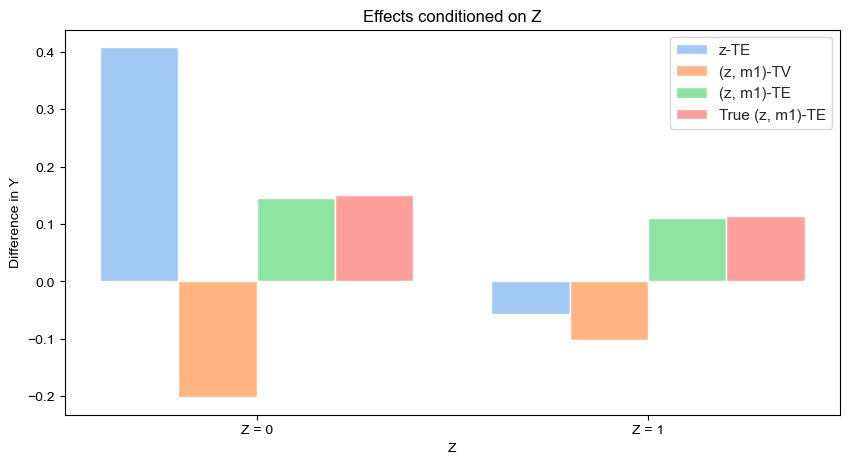

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

width = 0.3  # the width of the bars
padding = 0.3  # the padding between sets of bars
labels = ['Z = 0', 'Z = 1']
wx = np.arange(len(labels)) * (4 * width + padding)  # position for each set of bars

# Set the Seaborn color palette
sns.set(style="whitegrid")
palette = sns.color_palette("pastel")

# Plotting the bars with increased distance between collections
rects1 = ax.bar(wx - 1.5*width, probs[:, 0], width, label='z-TE', color=palette[0])
rects2 = ax.bar(wx - 0.5*width, probs[:, 1], width, label='(z, m1)-TV', color=palette[1])
rects3 = ax.bar(wx + 0.5*width, probs[:, 2], width, label='(z, m1)-TE', color=palette[2])
rects4 = ax.bar(wx + 1.5*width, probs[:, 3], width, label='True (z, m1)-TE', color=palette[3])

# Adding labels, title, and legend
ax.set_xlabel('Z')
ax.set_ylabel('Difference in Y')
ax.set_title('Effects conditioned on Z')
ax.set_xticks(wx)
ax.set_xticklabels(labels)
ax.legend()

In [21]:
bootstrap_n = 100

d1_samples = []
d2_samples = []

for _ in range(bootstrap_n):

    s1 = d1[np.random.choice(d1.shape[0], size=d1.shape[0], replace=True)]
    s2 = d2[np.random.choice(d2.shape[0], size=d2.shape[0], replace=True)]

    py_x1, py_x0 = naive_data(s1)
    py_x1m1, py_x0m1 = conditional_data(s1)
    pyx1_m1, pyx0_m1 = counterfactual_data(s1)

    d1_samples.append([py_x1 - py_x0, py_x1m1 - py_x0m1, pyx1_m1 - pyx0_m1])
    
    py_x1, py_x0 = naive_data(s2)
    py_x1m1, py_x0m1 = conditional_data(s2)
    pyx1_m1, pyx0_m1 = counterfactual_data(s2)

    d2_samples.append([py_x1 - py_x0, py_x1m1 - py_x0m1, pyx1_m1 - pyx0_m1])

In [22]:
d1_samples = np.array(d1_samples)
d2_samples = np.array(d2_samples)

In [23]:
np.percentile(d1_samples[:, 0], [2.5, 97.5])

array([0.387433  , 0.42227815])

In [24]:
ci_naive = np.array([
    (np.percentile(d1_samples[:, 0], [2.5, 97.5])),
    (np.percentile(d2_samples[:, 0], [2.5, 97.5]))
])

ci_conditional = np.array([
    (np.percentile(d1_samples[:, 1], [2.5, 97.5])),
    (np.percentile(d2_samples[:, 1], [2.5, 97.5]))
])

ci_counterfactual = np.array([
    (np.percentile(d1_samples[:, 2], [2.5, 97.5])),
    (np.percentile(d2_samples[:, 2], [2.5, 97.5]))
])

In [25]:
er_naive = [probs[:, 0] - ci_naive[:, 0], ci_naive[:, 1] - probs[:, 0]]
er_conditional = [probs[:, 1] - ci_conditional[:, 0], ci_conditional[:, 1] - probs[:, 1]]
er_counterfactual = [probs[:, 2] - ci_counterfactual[:, 0], ci_counterfactual[:, 1] - probs[:, 2]]

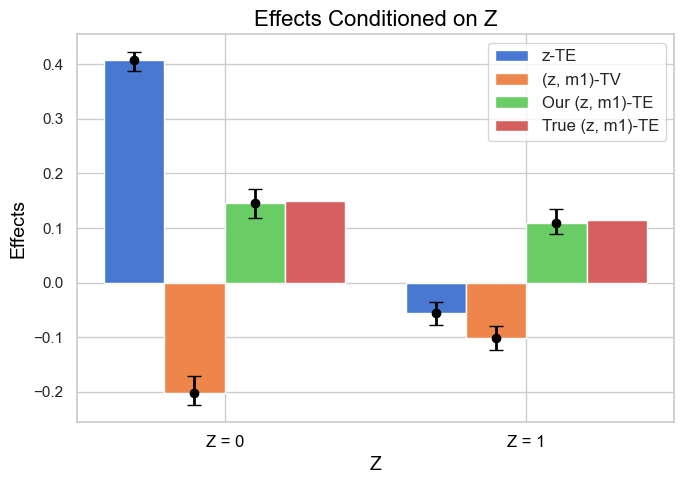

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))

width = 1  # Narrower bars
padding = 1  # Adjusted padding
labels = ['Z = 0', 'Z = 1']
wx = np.arange(len(labels)) * (4 * width + padding)

# Set the Seaborn style and color palette
sns.set(style="whitegrid")
palette = sns.color_palette("muted")

# Plotting the bars with improved aesthetics
rects1 = ax.bar(wx - 1.5*width, probs[:, 0], width, label='z-TE', color=palette[0])
rects2 = ax.bar(wx - 0.5*width, probs[:, 1], width, label='(z, m1)-TV', color=palette[1])
rects3 = ax.bar(wx + 0.5*width, probs[:, 2], width, label='Our (z, m1)-TE', color=palette[2])
rects4 = ax.bar(wx + 1.5*width, probs[:, 3], width, label='True (z, m1)-TE', color=palette[3])

# Customizing the error bars
ax.errorbar(wx - 1.5*width, probs[:, 0], yerr=er_naive, fmt='o', color='black', capsize=5, linewidth=2)
ax.errorbar(wx - 0.5*width, probs[:, 1], yerr=er_conditional, fmt='o', color='black', capsize=5, linewidth=2)
ax.errorbar(wx + 0.5*width, probs[:, 2], yerr=er_counterfactual, fmt='o', color='black', capsize=5, linewidth=2)

# Customizing labels, title, and legend
ax.set_xlabel('Z', fontsize=14, color='black')
ax.set_ylabel('Effects', fontsize=14, color='black')
ax.set_title('Effects Conditioned on Z', fontsize=16, color='black')
ax.set_xticks(wx)
ax.set_xticklabels(labels, fontsize=12, color='black')
ax.legend(fontsize=12)

# Improve the layout
plt.tight_layout()

# Save the plot
plt.savefig('pt.pdf')

# Show the plot
plt.show()

In [27]:
ci_naive 

array([[ 0.387433  ,  0.42227815],
       [-0.07694604, -0.03611373]])

In [28]:
probs[:, 0]

array([ 0.40783194, -0.05627188])

In [29]:
ci_naive - probs[:, 0].reshape(-1, 1)

array([[-0.02039894,  0.01444621],
       [-0.02067415,  0.02015816]])

In [30]:
0.40783194 - 0.4239364857161759

-0.016104545716175922